# Function 1 Description 
Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

In [15]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm

In [16]:
os.listdir()

['.ipynb_checkpoints',
 'function1.ipynb',
 'initial_inputs.npy',
 'initial_outputs.npy']

In [19]:
ii = np.load('initial_inputs.npy')
io = np.load('initial_outputs.npy')
df = pd.DataFrame(ii, columns=['x1', 'x2'])
df['io'] = io 

In [20]:
print(ii.shape)
print(io.shape)
df

(10, 2)
(10,)


,x1,x2,io
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


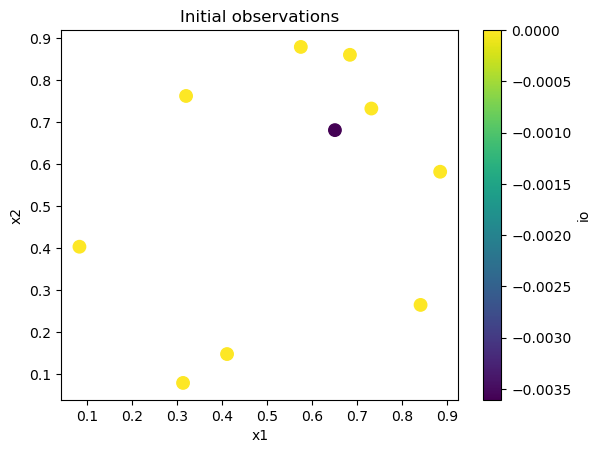

In [21]:
#taking advantage that this is a 2D function
plt.scatter(ii[:, 0], ii[:, 1], c=io, cmap='viridis', s=80)
plt.colorbar(label='io')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Initial observations')
plt.show()

In [61]:
def find_biggest_gap(list):
    list.sort()
    biggest_gap = 0
    gap_index = []
    for i in range(0, 9):
        current_gap = list[i+1] - list[i]
        if current_gap > biggest_gap:
            biggest_gap = current_gap
            gap_index = [i, i+1]
    return biggest_gap, gap_index

            

In [65]:
x1_0 = [float('%.8f'%(item[0])) for item in ii]
x1_1 = [float('%.8f'%(item[1])) for item in ii]
x1_0.sort()
x1_1.sort()
print(x1_0)
print(x1_1)

[0.08250725, 0.31269116, 0.31940389, 0.41043714, 0.57432921, 0.65011406, 0.68341817, 0.73102363, 0.84035342, 0.88388983]
[0.07872278, 0.1475543, 0.26473161, 0.40348751, 0.58225397, 0.68152635, 0.73299988, 0.76295937, 0.86105746, 0.8798981]


In [64]:
print(find_biggest_gap(x1_0))
print(find_biggest_gap(x1_1))


(0.23018391000000002, [0, 1])
(0.17876646000000002, [3, 4])


In [67]:
final_x1 = x1_0[0] + (0.23018391/2)
final_x2 = x1_1[3] + (0.17876646/2)
print('%.6f'%(final_x1), '%.6f'%(final_x2))

0.197599 0.492871
